# Neutrino simulation in SND@HL-LHC

This is a simple script to show to read and plot the info from the simulation file.
And how to do some basic cuts. We will use here RDataFrame as much as possible

## File Structure

There are two main TTrees in the File:

* gst Tree, containing the input GENIE neutrino interactions simulation
* cbmsim Tree, after the transport in the detector

**Note**: position units are different! gst uses **meters**, cbmsim uses **centimeters**. 

Instead, GeV is uses for energy/momenta in both files.

We first need to open both files and associate them to each other

In [1]:
import ROOT as r
inputfile = r.TFile.Open("/eos/experiment/sndlhc/users/aiulian/ADVSND/2026_09_08_allnu_AdvSND/benchmark/1/sndLHC.Genie-TGeant4.root")
gsttree = inputfile.Get("gst")
cbmsimtree = inputfile.Get("cbmsim")

cbmsimtree.AddFriend(gsttree)

Warning in <TClass::Init>: no dictionary for class ShipMCTrack is available
Warning in <TClass::Init>: no dictionary for class vetoPoint is available
Warning in <TClass::Init>: no dictionary for class FairMCPoint is available
Warning in <TClass::Init>: no dictionary for class FairMultiLinkedData_Interface is available
Warning in <TClass::Init>: no dictionary for class FairMultiLinkedData is available
Warning in <TClass::Init>: no dictionary for class FairLink is available
Warning in <TClass::Init>: no dictionary for class AdvTargetPoint is available
Warning in <TClass::Init>: no dictionary for class AdvMuFilterPoint is available
Warning in <TClass::Init>: no dictionary for class FairMCEventHeader is available
Warning in <TClass::Init>: no dictionary for class FairFileHeader is available


In [2]:
%jsroot off
df = r.RDataFrame(cbmsimtree)
df.GetColumnNames()

vector<string>{ "AdvMuFilterPoint", "AdvMuFilterPoint.fBits", "AdvMuFilterPoint.fDetectorID", "AdvMuFilterPoint.fELoss", "AdvMuFilterPoint.fEventId", "AdvMuFilterPoint.fLength", "AdvMuFilterPoint.fLink", "AdvMuFilterPoint.fPdgCode", "AdvMuFilterPoint.fPx", "AdvMuFilterPoint.fPy", "AdvMuFilterPoint.fPz", "AdvMuFilterPoint.fTime", "AdvMuFilterPoint.fTrackID", "AdvMuFilterPoint.fUniqueID", "AdvMuFilterPoint.fX", "AdvMuFilterPoint.fY", "AdvMuFilterPoint.fZ", "AdvTargetPoint", "AdvTargetPoint.fBits", "AdvTargetPoint.fDetectorID", "AdvTargetPoint.fELoss", "AdvTargetPoint.fEventId", "AdvTargetPoint.fExitX", "AdvTargetPoint.fExitY", "AdvTargetPoint.fExitZ", "AdvTargetPoint.fLength", "AdvTargetPoint.fLink", "AdvTargetPoint.fPdgCode", "AdvTargetPoint.fPx", "AdvTargetPoint.fPy", "AdvTargetPoint.fPz", "AdvTargetPoint.fTime", "AdvTargetPoint.fTrackID", "AdvTargetPoint.fUniqueID", "AdvTargetPoint.fX", "AdvTargetPoint.fY", "AdvTargetPoint.fZ", "MCEventHeader.", "MCEventHeader.TNamed", "MCEventHeader.

## Drawing Neutrino Interaction Info

For example, common plots are the vertex position and neutrino energy

In [3]:
gsttree.Scan("vtxz:vtxy")

************************************
*    Row   *      vtxz *      vtxy *
************************************
*        0 * 1.8486234 * 0.3939548 *
*        1 * 1.7060429 * 0.3532472 *
*        2 * 1.6411853 * 0.4752769 *
*        3 * 1.8710399 * 0.6840492 *
*        4 * 2.0339984 * 0.3698356 *
*        5 * 1.8850253 * 0.7008100 *
*        6 * 1.8045731 * 0.5359343 *
*        7 * 2.1875179 * 0.8594213 *
*        8 * 1.4936939 * 0.4385238 *
*        9 * 1.6225734 * 0.3956201 *
*       10 * 1.9300734 * 0.5686310 *
*       11 * 1.8588864 * 0.6180623 *
*       12 * 2.0203587 * 0.7063701 *
*       13 * 1.4818221 * 0.5952220 *
*       14 * 1.9766898 * 0.5355959 *
*       15 * 2.1137971 * 0.4989669 *
*       16 * 2.1863543 * 0.6532272 *
*       17 * 2.3051319 * 0.5302323 *
*       18 * 1.9859625 * 0.4484475 *
*       19 * 1.8726977 * 0.5908463 *
*       20 * 2.0643033 * 0.5630457 *
*       21 * 1.8115668 * 0.6671241 *
*       22 * 1.5106784 * 0.6880252 *
*       23 * 1.9613773 * 0.3871078 *
*

Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or q to quit ==> Type <CR> to continue or 

1000

In [4]:
hvzy = df.Histo2D(("hvzy","Neutrino vertex position;z[m];y[m]",100,1.4,2.4,100,0.,1.0),"vtxz","vtxy")
hnuE = df.Histo1D("Ev")

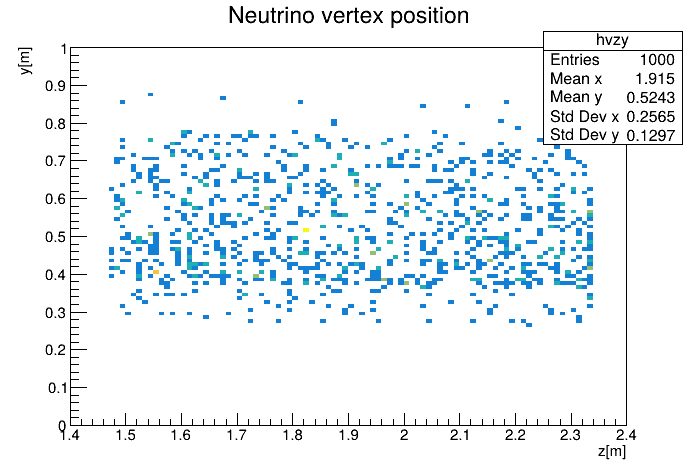

In [5]:
czy = r.TCanvas()
hvzy.DrawClone()
czy.Draw()

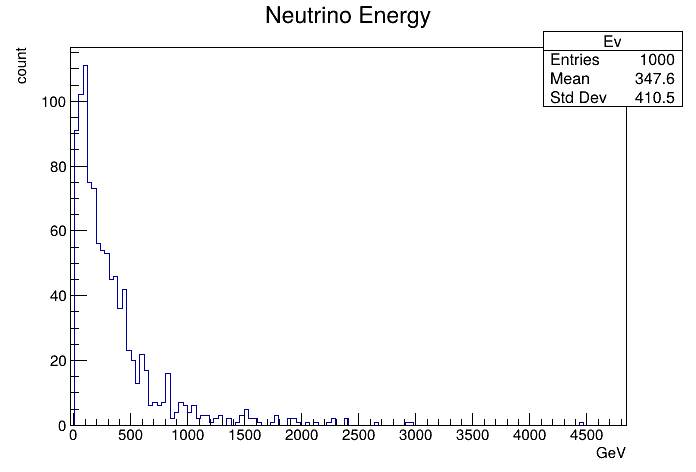

In [6]:
cE = r.TCanvas()
hnuE.SetTitle("Neutrino Energy;GeV")
hnuE.DrawClone()
cE.Draw()

## Drawing Detector Info

Let's now have a loot at the other file. For example, the energy deposit in the calorimeter

In [7]:
hEloss = df.Histo1D("AdvMuFilterPoint.fELoss")

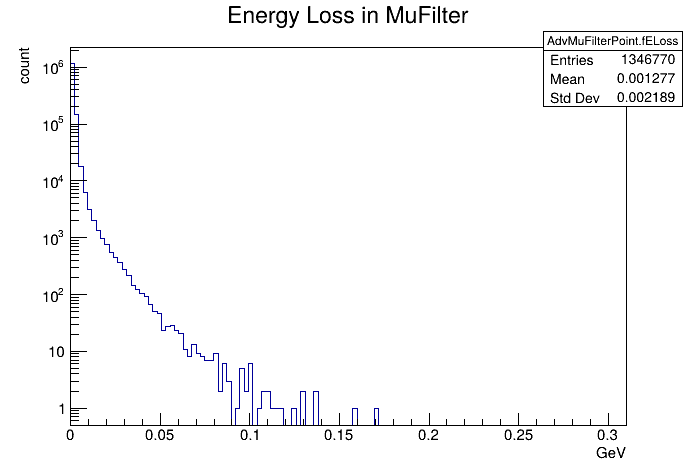

In [8]:
cE_MuFilter = r.TCanvas()
hEloss.Draw()
hEloss.SetTitle("Energy Loss in MuFilter;GeV")
cE_MuFilter.SetLogy()
cE_MuFilter.Draw()

## Combining the two information

Since the two trees are coupled together, we can apply a filter from gst nu information and check how the detector propagation changes

In [9]:
dfnueCC = df.Filter("TMath::Abs(neu)==12").Filter("cc")
dfnumuCC = df.Filter("TMath::Abs(neu)==14").Filter("cc")

In [10]:
hEtargetloss_nueCC = dfnueCC.Histo1D("AdvTargetPoint.fELoss")
hEtargetloss_numuCC = dfnumuCC.Histo1D("AdvTargetPoint.fELoss")

In [ ]:
cE_TargetLossCompare = r.TCanvas()
hEtargetloss_numuCC.SetLineColor(r.kRed)
hEtargetloss_numuCC.Scale(1./hEtargetloss_numuCC.Integral())
hEtargetloss_numuCC.DrawClone("histo")
hEtargetloss_nueCC.Scale(1./hEtargetloss_nueCC.Integral())
hEtargetloss_nueCC.SetTitle("Energy Loss in Target Comparison;GeV")
hEtargetloss_nueCC.DrawClone("SAMES&&histo")
cE_TargetLossCompare.SetLogy()
cE_TargetLossCompare.Draw()

# Some display of hit distributions for an event
Useful to have an idea of the difference

In [ ]:
eventID_nue = 2
dfnueCC_singleevent = dfnueCC.Range(eventID_nue,eventID_nue+1)
eventID_numu = 1
dfnumuCC_singleevent = dfnumuCC.Range(eventID_numu,eventID_numu+1)

In [ ]:
targetzy_singleevent_nueCC = dfnueCC_singleevent.Graph("AdvTargetPoint.fZ","AdvTargetPoint.fY")
targetzy_singleevent_numuCC = dfnumuCC_singleevent.Graph("AdvTargetPoint.fZ","AdvTargetPoint.fY")

mufilterzy_singleevent_nueCC = dfnueCC_singleevent.Graph("AdvMuFilterPoint.fZ","AdvMuFilterPoint.fY")
mufilterzy_singleevent_numuCC = dfnumuCC_singleevent.Graph("AdvMuFilterPoint.fZ","AdvMuFilterPoint.fY")

In [ ]:
%jsroot off
cnue_display = r.TCanvas()
targetzy_singleevent_nueCC.SetTitle("ZY distribution in target, single event nueCC;z[cm];y[cm]")
targetzy_singleevent_nueCC.DrawClone("AP*")
cnue_display.Draw()

In [ ]:
cnumu_display = r.TCanvas()
targetzy_singleevent_numuCC.SetTitle("ZY distribution in target, single event numuCC;z[cm];y[cm]")
targetzy_singleevent_numuCC.DrawClone("AP*")
cnumu_display.Draw()

### The difference becomes even more clear from the mufilter comparison

In [ ]:
%jsroot off
cnue_display = r.TCanvas()
#draw the two graphs together
gnue = r.TMultiGraph()
gnue.Add(targetzy_singleevent_nueCC.GetValue())

mufilterzy_singleevent_nueCC.SetMarkerColor(r.kRed)

gnue.Add(mufilterzy_singleevent_nueCC.GetValue())
gnue.SetTitle("ZY distribution, single event, nueCC;z[cm];y[cm]")
gnue.Draw("AP*")
cnue_display.DrawClone()

In [ ]:
%jsroot off
cnumu_display = r.TCanvas()
#draw the two graphs together
gnumu = r.TMultiGraph()
gnumu.Add(targetzy_singleevent_numuCC.GetValue())

mufilterzy_singleevent_numuCC.SetMarkerColor(r.kRed)

gnumu.Add(mufilterzy_singleevent_numuCC.GetValue())
gnumu.SetTitle("ZY distribution, single event, numuCC;z[cm];y[cm]")
gnumu.Draw("AP*")
cnumu_display.DrawClone()